In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/autonomous_driving_expanded_dataset.csv")

print("Shape:", df.shape)

Shape: (5000, 19)


In [ ]:
categorical_cols = ["weather_condition", "road_surface_condition"]
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
le = LabelEncoder()
df["behavior_label"] = le.fit_transform(df["behavior_label"])

In [ ]:
core_features = [
    'obstacle_distance_m',
    'relative_speed_mps',
    'num_obstacles',
    'lane_offset_m',
    'traffic_density_veh_per_km',
    'risk_probability',
    'visibility_range_m'
]

X = df[core_features]
y = df["behavior_label"]

In [ ]:
np.random.seed(42)
noise = np.random.normal(0, 0.02, X.shape)
X_noisy = X + noise

In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_noisy,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=80,
    max_depth=8,
    min_samples_split=15,
    min_samples_leaf=8,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.972
Precision: 0.972504476386078
Recall: 0.972
F1 Score: 0.9721119262946992

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       562
           1       0.97      0.99      0.98       148
           2       0.96      0.98      0.97        47
           3       0.94      0.94      0.94       178
           4       0.91      0.98      0.95        65

    accuracy                           0.97      1000
   macro avg       0.95      0.97      0.96      1000
weighted avg       0.97      0.97      0.97      1000



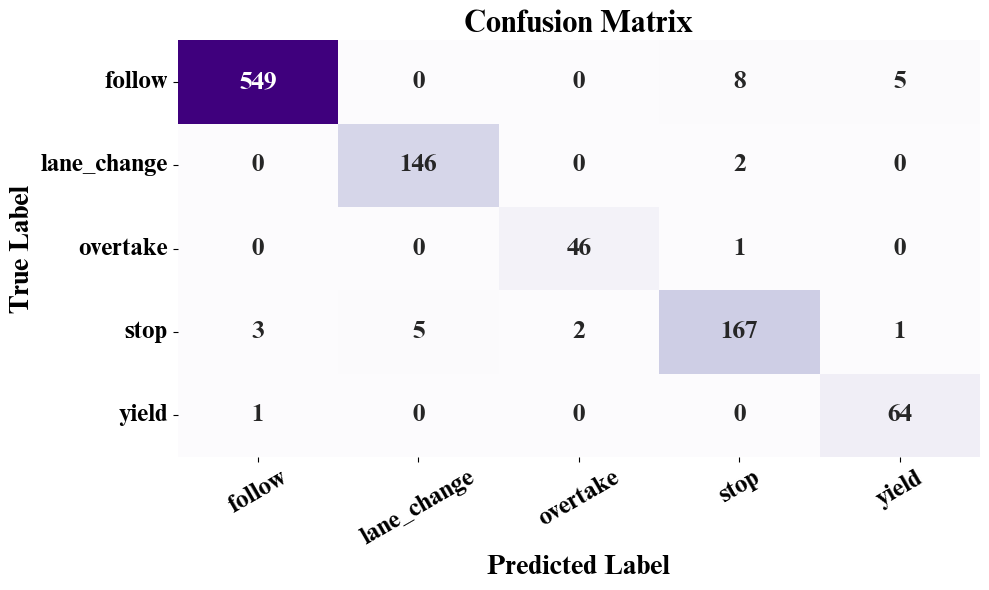

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import font_manager as fm
from sklearn.metrics import confusion_matrix


font_path = "/content/times new roman bold.ttf"
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['font.weight'] = 'bold'


y_pred = rf.predict(X_test)


class_names = le.classes_


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,6))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    cbar=False,
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={
        "fontsize":18,
        "fontweight":"bold",
        "fontfamily":font_name
    }
)


plt.title("Confusion Matrix",
          fontsize=22,
          fontweight='bold',
          fontname=font_name)

plt.xlabel("Predicted Label",
           fontsize=20,
           fontweight='bold',
           fontname=font_name)

plt.ylabel("True Label",
           fontsize=20,
           fontweight='bold',
           fontname=font_name)


ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=30,
    fontsize=18,
    fontweight='bold',
    fontname=font_name
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=18,
    fontweight='bold',
    fontname=font_name
)

plt.tight_layout()
plt.grid(False)
plt.show()

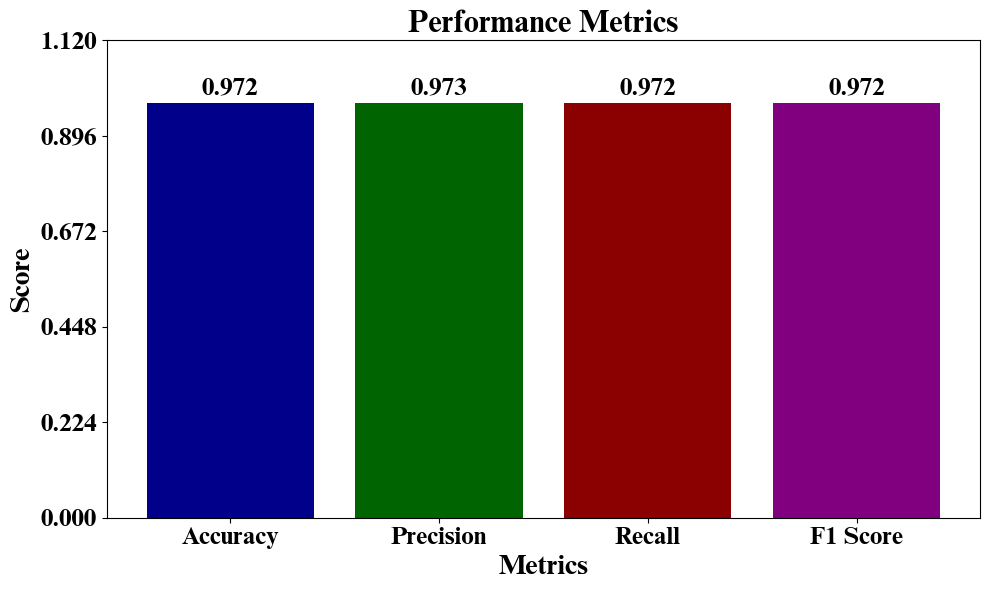

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

font_path = "/content/times new roman bold.ttf"
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()


accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values  = [accuracy, precision, recall, f1]

plt.figure(figsize=(10,6))
bars = plt.bar(metrics, values,
               color=['darkblue','darkgreen','darkred','purple'])


max_val = max(values)
plt.ylim(0, min(1.1, max_val + 0.15))


yticks = np.linspace(0, round(max_val + 0.15, 2), 6)
plt.yticks(yticks, fontsize=18, fontweight='bold', fontname=font_name)


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.02,
             f'{height:.3f}',
             ha='center',
             fontsize=18,
             fontweight='bold',
             fontname=font_name)

plt.title("Performance Metrics",
          fontsize=22, fontweight='bold', fontname=font_name)

plt.xlabel("Metrics",
           fontsize=20, fontweight='bold', fontname=font_name)

plt.ylabel("Score",
           fontsize=20, fontweight='bold', fontname=font_name)

plt.xticks(fontsize=18, fontweight='bold', fontname=font_name)

plt.grid(False)
plt.tight_layout()
plt.show()

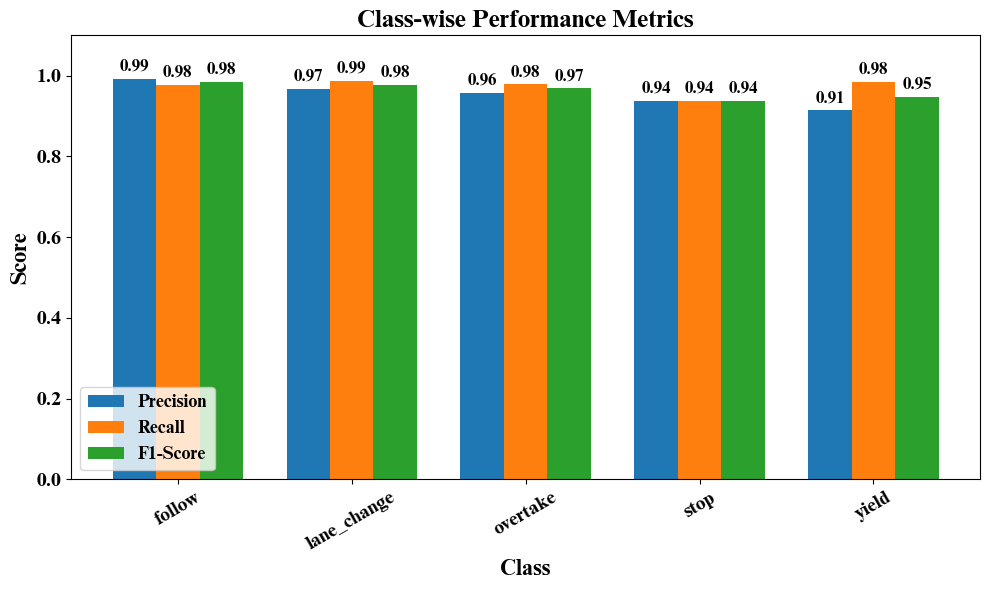

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import precision_score, recall_score, f1_score


font_path = "/content/times new roman bold.ttf"
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()


y_pred = rf.predict(X_test)

classes = np.unique(y_test)
class_names = le.inverse_transform(classes)

precision = precision_score(y_test, y_pred, average=None)
recall    = recall_score(y_test, y_pred, average=None)
f1        = f1_score(y_test, y_pred, average=None)


x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width, precision, width, label='Precision')
bars2 = plt.bar(x, recall, width, label='Recall')
bars3 = plt.bar(x + width, f1, width, label='F1-Score')

plt.xticks(x, class_names, rotation=30,
           fontsize=14, fontweight='bold', fontname=font_name)

plt.yticks(fontsize=14, fontweight='bold', fontname=font_name)
plt.xlabel("Class", fontsize=16, fontweight='bold', fontname=font_name)
plt.ylabel("Score", fontsize=16, fontweight='bold', fontname=font_name)
plt.title("Class-wise Performance Metrics",
          fontsize=18, fontweight='bold', fontname=font_name)

plt.ylim(0, 1.1)

legend = plt.legend(prop={'family': font_name, 'size': 13, 'weight': 'bold'})


for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height + 0.02,
                 f'{height:.2f}',
                 ha='center',
                 fontsize=12,
                 fontweight='bold',
                 fontname=font_name)

plt.tight_layout()
plt.show()

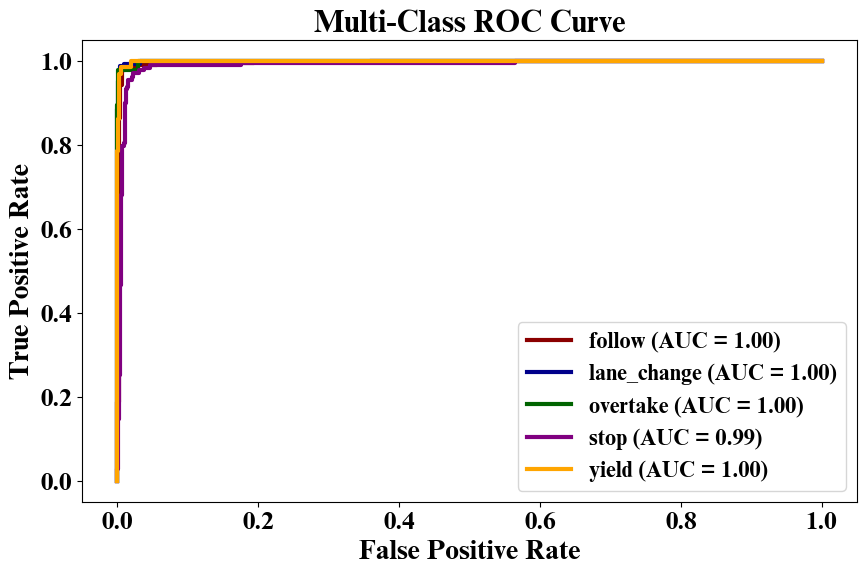

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


font_path = "/content/times new roman bold.ttf"
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()


class_names = ['follow', 'lane_change', 'overtake', 'stop', 'yield']

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)


y_prob = rf.predict_proba(X_test)

plt.figure(figsize=(10,6))

colors = ['darkred', 'darkblue', 'darkgreen', 'purple', 'orange']

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr,
             color=colors[i],
             linewidth=3,
             label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.title("Multi-Class ROC Curve", fontsize=22, fontweight='bold', fontname=font_name)
plt.xlabel("False Positive Rate", fontsize=20, fontweight='bold', fontname=font_name)
plt.ylabel("True Positive Rate", fontsize=20, fontweight='bold', fontname=font_name)

plt.xticks(fontsize=18, fontweight='bold', fontname=font_name)
plt.yticks(fontsize=18, fontweight='bold', fontname=font_name)

plt.legend(prop={'family':font_name,'weight':'bold','size':16})
plt.grid(False)
plt.show()

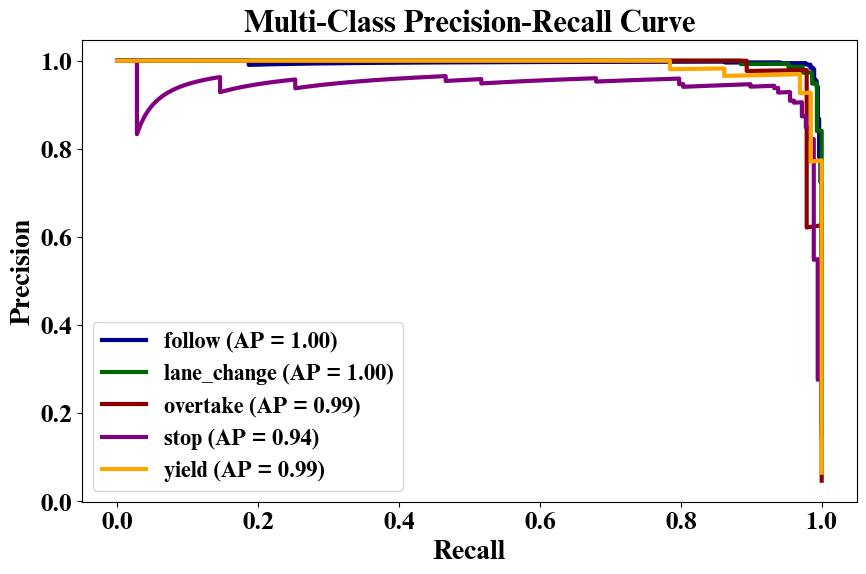

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score


font_path = "/content/times new roman bold.ttf"
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()


class_names = ['follow', 'lane_change', 'overtake', 'stop', 'yield']


classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)


y_prob = rf.predict_proba(X_test)

plt.figure(figsize=(10,6))

colors = ['darkblue', 'darkgreen', 'darkred', 'purple', 'orange']

for i in range(len(classes)):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    ap_score = average_precision_score(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    plt.plot(recall, precision,
             color=colors[i],
             linewidth=3,
             label=f"{class_names[i]} (AP = {ap_score:.2f})")

plt.title("Multi-Class Precision-Recall Curve",
          fontsize=22, fontweight='bold', fontname=font_name)

plt.xlabel("Recall",
           fontsize=20, fontweight='bold', fontname=font_name)

plt.ylabel("Precision",
           fontsize=20, fontweight='bold', fontname=font_name)

plt.xticks(fontsize=18, fontweight='bold', fontname=font_name)
plt.yticks(fontsize=18, fontweight='bold', fontname=font_name)

plt.legend(prop={'family':font_name,'weight':'bold','size':16})
plt.grid(False)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
)

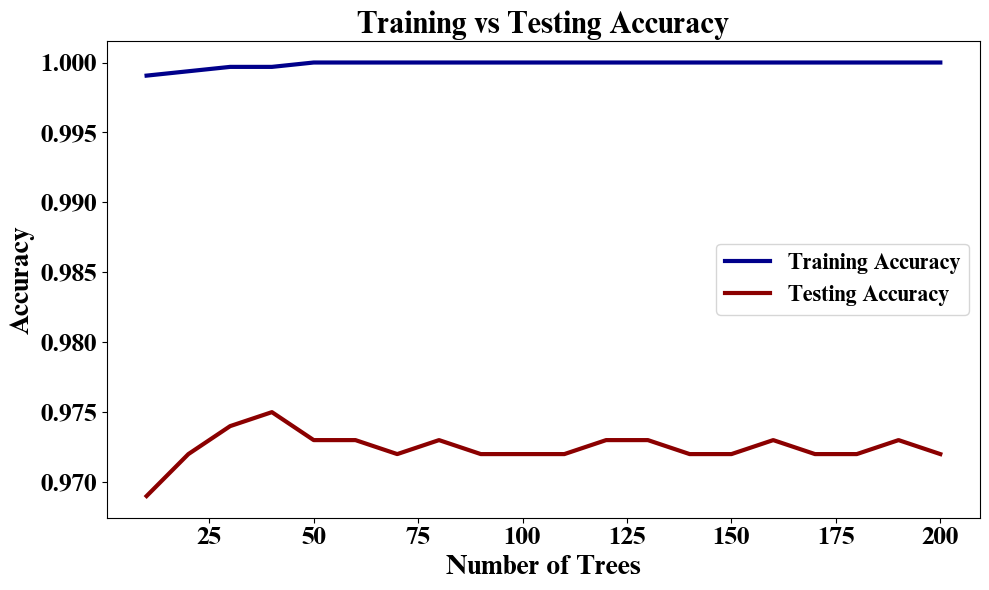

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

=
font_path = "/content/times new roman bold.ttf"
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()


estimators_range = range(10, 201, 10)

train_acc = []
test_acc = []

for n in estimators_range:
    rf_temp = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )
    rf_temp.fit(X_train, y_train)


    y_train_pred = rf_temp.predict(X_train)
    train_acc.append(accuracy_score(y_train, y_train_pred))


    y_test_pred = rf_temp.predict(X_test)
    test_acc.append(accuracy_score(y_test, y_test_pred))


plt.figure(figsize=(10,6))

plt.plot(estimators_range, train_acc,
         color='darkblue',
         linewidth=3,
         label='Training Accuracy')

plt.plot(estimators_range, test_acc,
         color='darkred',
         linewidth=3,
         label='Testing Accuracy')

plt.title("Training vs Testing Accuracy",
          fontsize=22, fontweight='bold', fontname=font_name)

plt.xlabel("Number of Trees",
           fontsize=20, fontweight='bold', fontname=font_name)

plt.ylabel("Accuracy",
           fontsize=20, fontweight='bold', fontname=font_name)

plt.xticks(fontsize=18, fontweight='bold', fontname=font_name)
plt.yticks(fontsize=18, fontweight='bold', fontname=font_name)

plt.legend(prop={'family':font_name,'weight':'bold','size':16})

plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
%who

LabelEncoder	 MinMaxScaler	 RandomForestClassifier	 X	 X_noisy	 X_scaled	 X_test	 X_train	 accuracy	 
accuracy_score	 ap_score	 auc	 average_precision_score	 ax	 bar	 bars	 categorical_cols	 class_names	 
classes	 classification_report	 cm	 colors	 confusion_matrix	 core_features	 df	 f1	 f1_score	 
fm	 font_name	 font_path	 fpr	 height	 i	 label_binarize	 le	 max_val	 
metrics	 noise	 np	 pd	 plt	 precision	 precision_recall_curve	 precision_score	 prop	 
recall	 recall_score	 rf	 roc_auc	 roc_curve	 scaler	 sns	 tpr	 train_test_split	 
values	 y	 y_pred	 y_prob	 y_test	 y_test_bin	 y_train	 yticks	 


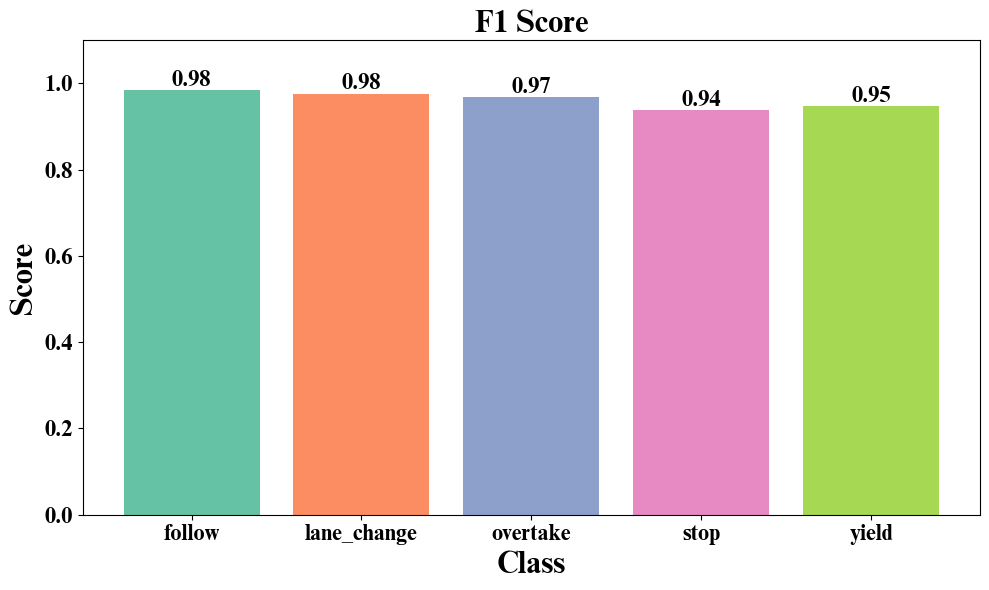

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import f1_score


prop = fm.FontProperties(fname=font_path)


y_pred = rf.predict(X_test)


classes = np.unique(y_test)


real_class_names = le.inverse_transform(classes)


f1_scores = f1_score(y_test, y_pred, average=None)


plt.figure(figsize=(10,6))

colors = plt.cm.Set2.colors[:len(real_class_names)]

bars = plt.bar(real_class_names, f1_scores, color=colors)


for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.2f}",
        ha='center',
        fontsize=16,
        fontproperties=prop
    )

plt.title("F1 Score",
          fontproperties=prop,
          fontsize=22)

plt.ylabel("Score",
           fontproperties=prop,
           fontsize=22)
plt.xlabel("Class",
           fontproperties=prop,
           fontsize=22)
ax = plt.gca()
for label in ax.get_xticklabels():
    label.set_fontproperties(prop)
    label.set_fontsize(16)

for label in ax.get_yticklabels():
    label.set_fontproperties(prop)
    label.set_fontsize(16)

plt.ylim(0, 1.1)

plt.tight_layout()
plt.show()